# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

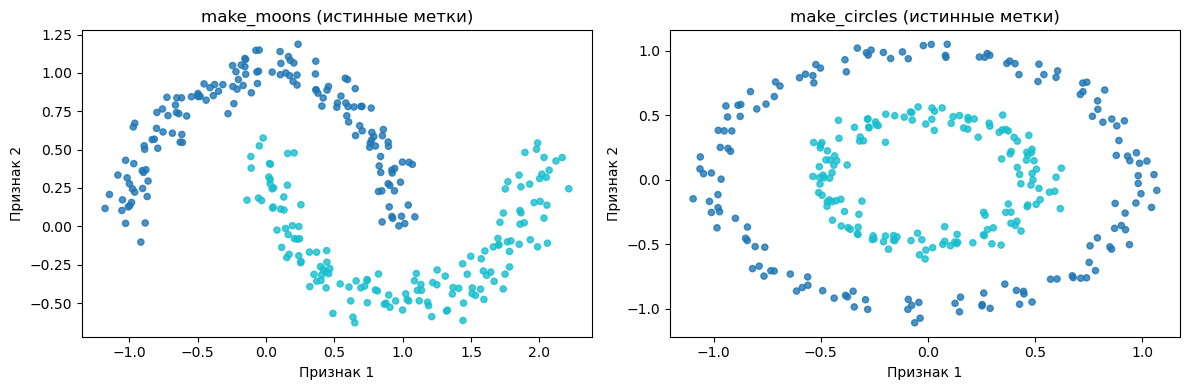

In [30]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

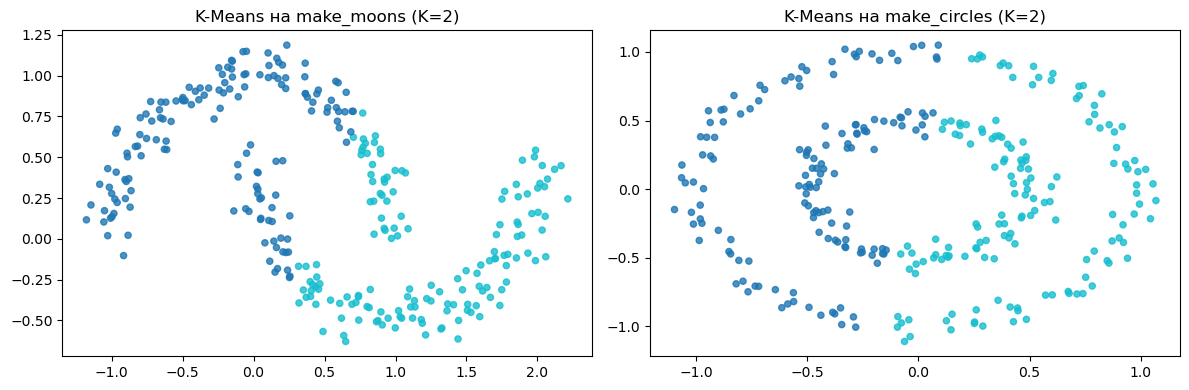

In [31]:
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()


**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

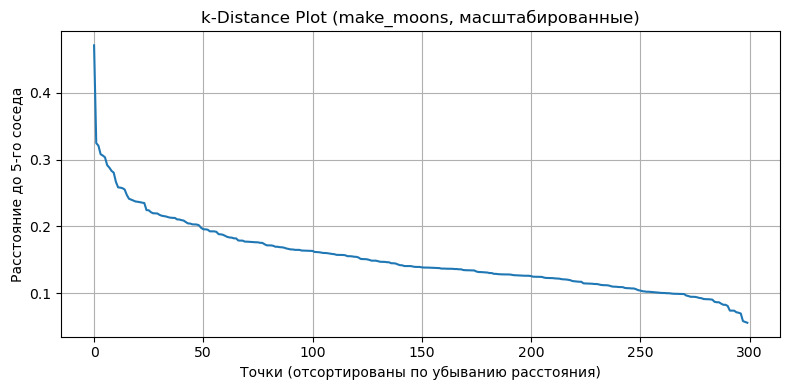

Найдите 'локоть' на графике и запишите подходящее значение eps:
Ответ: Оптимальное значение eps находится в точке изгиба ('локтя') графика, где быстрый рост расстояний сменяется плавным плато (обычно в районе 0.2–0.35 для масштабированных лун).


In [32]:
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)
distances, _ = nn.kneighbors(X_moons_scaled)

k_distances_moons = np.sort(distances[:, k - 1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")
print("Ответ: Оптимальное значение eps находится в точке изгиба ('локтя') графика, где быстрый рост расстояний сменяется плавным плато (обычно в районе 0.2–0.35 для масштабированных лун).")


**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

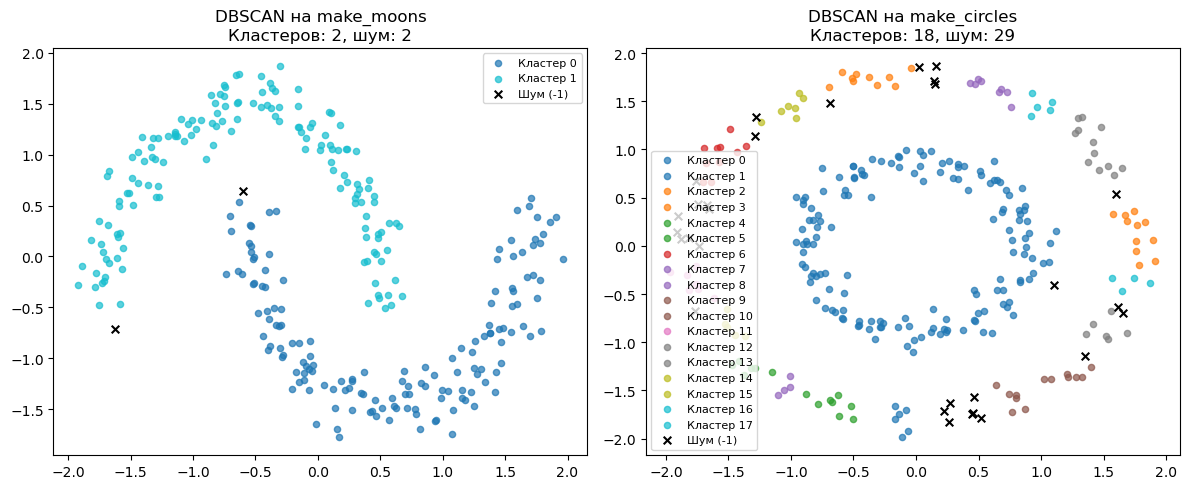

In [33]:
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

db_moons = DBSCAN(eps=0.25, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.2, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = plt.cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [34]:
kmeans_eval = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_eval_km = kmeans_eval.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, labels_eval_km)

non_noise_mask = labels_db_moons != -1
score_dbscan = silhouette_score(X_moons_scaled[non_noise_mask], labels_db_moons[non_noise_mask])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.387


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

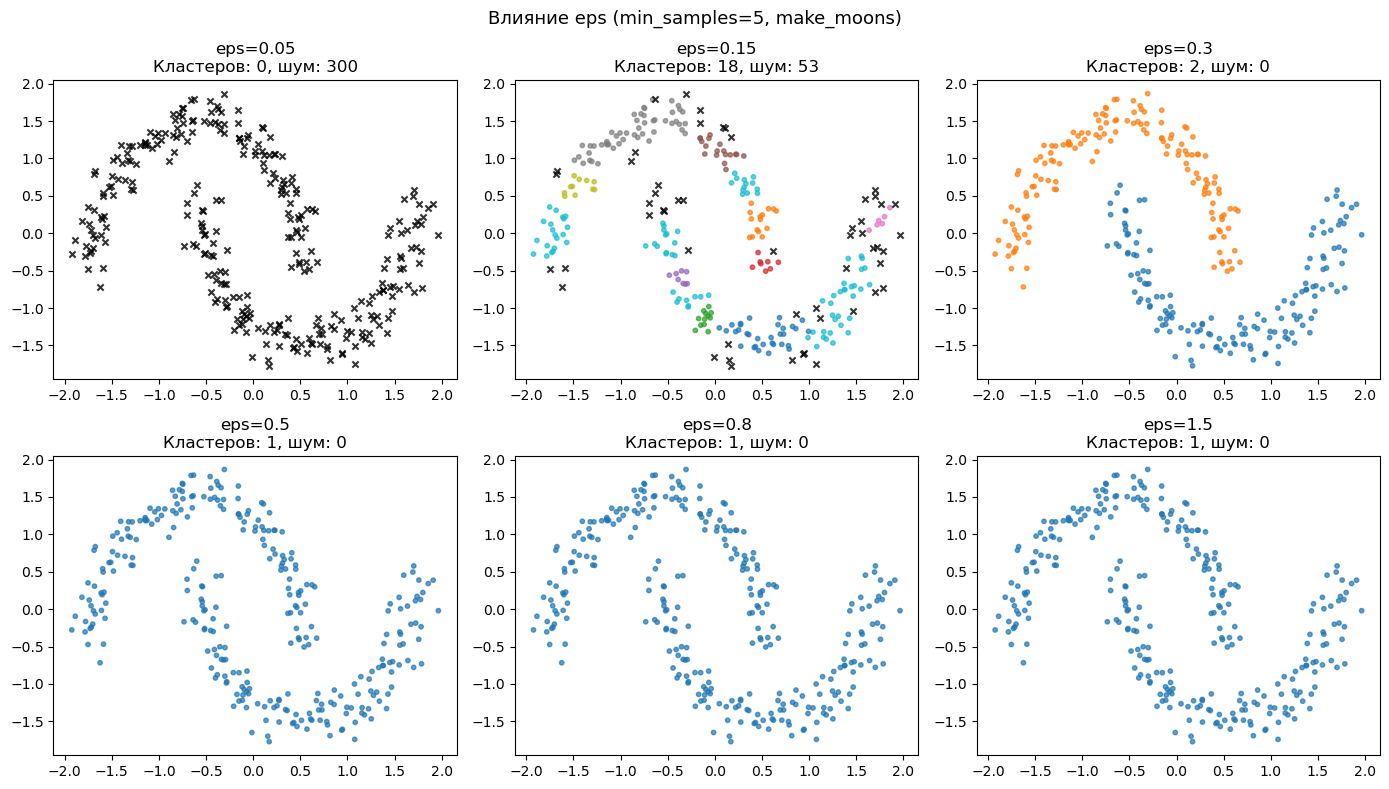

In [35]:
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    db_i = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = db_i.fit_predict(X_moons_scaled)
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        
        noise_mask = labels_i == -1
        
        axes[i].scatter(X_moons_scaled[~noise_mask, 0], X_moons_scaled[~noise_mask, 1],
                        c=labels_i[~noise_mask], cmap='tab10', s=10, alpha=0.7, vmin=0, vmax=9)
        
        axes[i].scatter(X_moons_scaled[noise_mask, 0], X_moons_scaled[noise_mask, 1],
                        c='black', marker='x', s=20, alpha=0.8)
        
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [36]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

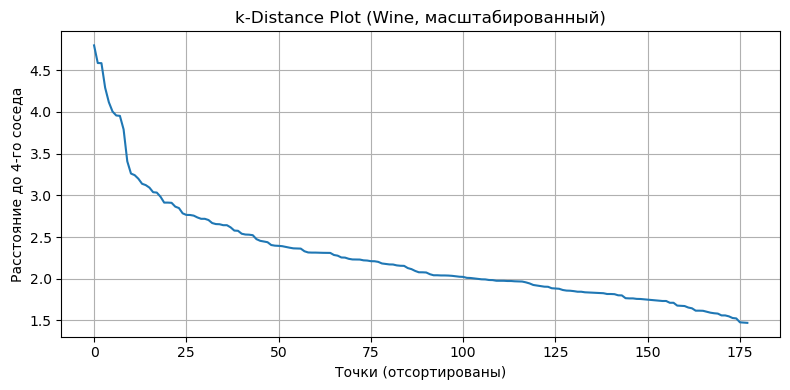

In [37]:
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

k_wine = 4
nn_wine = NearestNeighbors(n_neighbors=k_wine)
nn_wine.fit(X_wine_scaled)
distances_wine, _ = nn_wine.kneighbors(X_wine_scaled)

k_dist_wine = np.sort(distances_wine[:, k_wine - 1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
eps_wine = 2.3

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_ratio_wine = n_noise_wine / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"Число кластеров: {n_clusters_wine}")
print(f"Число шумовых точек: {n_noise_wine}")
print(f"Доля шума: {noise_ratio_wine:.2%}")

if n_clusters_wine > 1:
    non_noise_mask = labels_wine != -1
    score_wine = silhouette_score(X_wine_scaled[non_noise_mask], labels_wine[non_noise_mask])
    print(f"Коэффициент силуэта (без шума): {score_wine:.3f}")
else:
    print("Коэффициент силуэта: невозможно вычислить (выделен 1 кластер или меньше)")

=== Результаты DBSCAN на Wine ===
Число кластеров: 2
Число шумовых точек: 36
Доля шума: 20.22%
Коэффициент силуэта (без шума): 0.325


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [39]:
noise_mask_wine = labels_wine == -1
X_wine_noise = X_wine[noise_mask_wine]

df_noise = pd.DataFrame(X_wine_noise, columns=df_wine.columns)
mean_noise = df_noise.mean()
mean_global = df_wine.mean()

comparison_df = pd.DataFrame({
    'Global Mean': mean_global,
    'Noise Mean': mean_noise,
    'Abs Difference': (mean_global - mean_noise).abs()
}).sort_values(by='Abs Difference', ascending=False)

print("=== Средние значения признаков ===")
print(comparison_df.round(2))

print("Наиболее сильно от средних значений по всей выборке отличаются признаки с максимальной абсолютной разницей")

=== Средние значения признаков ===
                              Global Mean  Noise Mean  Abs Difference
proline                            746.89      650.78           96.12
magnesium                           99.74      102.39            2.65
color_intensity                      5.06        4.31            0.75
alcalinity_of_ash                   19.49       20.20            0.71
alcohol                             13.00       12.58            0.42
proanthocyanins                      1.59        1.84            0.25
malic_acid                           2.34        2.47            0.13
total_phenols                        2.30        2.37            0.08
od280/od315_of_diluted_wines         2.61        2.54            0.07
hue                                  0.96        1.00            0.04
nonflavanoid_phenols                 0.36        0.38            0.02
flavanoids                           2.03        2.01            0.02
ash                                  2.37        2.36  

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Сравнение силуэта на Wine
K-Means (K=3): 0.285
DBSCAN:        0.325


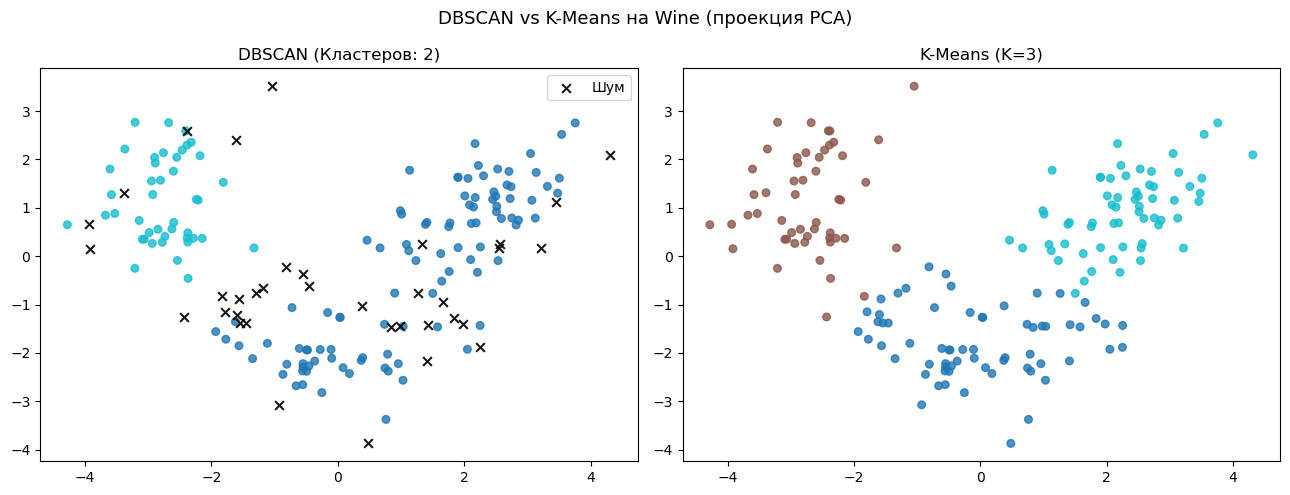

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

kmeans_wine = KMeans(n_clusters=3, random_state=RANDOM_STATE)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)

score_km_wine = silhouette_score(X_wine_scaled, labels_km_wine)

if n_clusters_wine > 1:
    non_noise_mask = labels_wine != -1
    score_db_wine = silhouette_score(X_wine_scaled[non_noise_mask], labels_wine[non_noise_mask])
else:
    score_db_wine = float('nan')

print("Сравнение силуэта на Wine")
print(f"K-Means (K=3): {score_km_wine:.3f}")
print(f"DBSCAN:        {score_db_wine:.3f}" if not np.isnan(score_db_wine) else "DBSCAN: невозможно вычислить")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

noise_mask = labels_wine == -1
axes[0].scatter(X_wine_2d[~noise_mask, 0], X_wine_2d[~noise_mask, 1], 
                c=labels_wine[~noise_mask], cmap='tab10', s=30, alpha=0.8)
axes[0].scatter(X_wine_2d[noise_mask, 0], X_wine_2d[noise_mask, 1], 
                c='black', marker='x', s=40, alpha=0.9, label='Шум')
axes[0].set_title(f"DBSCAN (Кластеров: {n_clusters_wine})")
axes[0].legend()

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], 
                c=labels_km_wine, cmap='tab10', s=30, alpha=0.8)
axes[1].set_title("K-Means (K=3)")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> DBSCAN выигрывает, если количество кластеров заранее неизвестно, либо они имеют разный размер. Также, это происходит, когда данные имеют сложную нелинейную форму, либо в датасете много выбросов.

**2. Когда K-Means предпочтительнее?**

> K-Means более предпочтителен, когда датасет имеет огромный размер, данные имеют разную плотность кластеров, либо высокую размерность.

**3. Почему масштабирование обязательно для DBSCAN?**

> Масштабрование необходимо для корректности евклидова расстояния. Также, масштабирование нужно для "равноправного" анализа "приоритета" среди соседей. 

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки в датасете Wine — это уникальные образцы с аномальным составом, пограничные вина-гибриды или лабораторный брак, которые химически сильно выбиваются из стандартных сортов.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет, нельзя, по следующим причинам: 1. Алгоритмы могут найти в одном датасете разное количество групп, из-за чего теряется сравнительный смысл в усреднении 2. Разное отношение к шуму, K-Means должен включать в себя абсолютно все точки в кластеры, в то время как DBSCAN позволяет себе отбрасывать шумы, беря в расчёт только "хорошие" плотные ядра кластера.